In [1]:
import os, time as _time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import pyvista as pv
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot


In [2]:
import pickle

with open(Path.cwd() / 'noise_samples.pkl', 'rb') as f:
    noise_samples = pickle.load(f)

stage_names = list(noise_samples.keys())
print(f"{len(stage_names)} stages: {stage_names}")
for name in stage_names:
    arr = np.asarray(noise_samples[name])
    print(f"{name:25s} n={arr.size:>8d}  mean={arr.mean():>12.3f}  std={arr.std():>12.3f}")


11 stages: ['raw', '0 Mute Traces', '1 Flip Image', '2 Remove Mean', '3 Interpolate Clipping', '4 Ormsby Bandpass', '5 Remove SVD', '6 Crop Samples', '7 Constant Velocity', '8 Spherical Gain', '9 Crop Samples']
raw                       n=  976244  mean=    3024.005  std=     341.921
0 Mute Traces             n=  976244  mean=    3024.005  std=     341.921
1 Flip Image              n=  976244  mean=    3024.005  std=     341.921
2 Remove Mean             n=  976244  mean=       4.495  std=      11.090
3 Interpolate Clipping    n=  976244  mean=       4.495  std=      11.090
4 Ormsby Bandpass         n=  976244  mean=       9.334  std=      10.495
5 Remove SVD              n=  976244  mean=       0.118  std=       9.233
6 Crop Samples            n=  976244  mean=       0.118  std=       9.233
7 Constant Velocity       n=  976244  mean=       0.118  std=       9.233
8 Spherical Gain          n=  976244  mean=    2402.272  std=  171156.107
9 Crop Samples            n=  976244  mean=    24

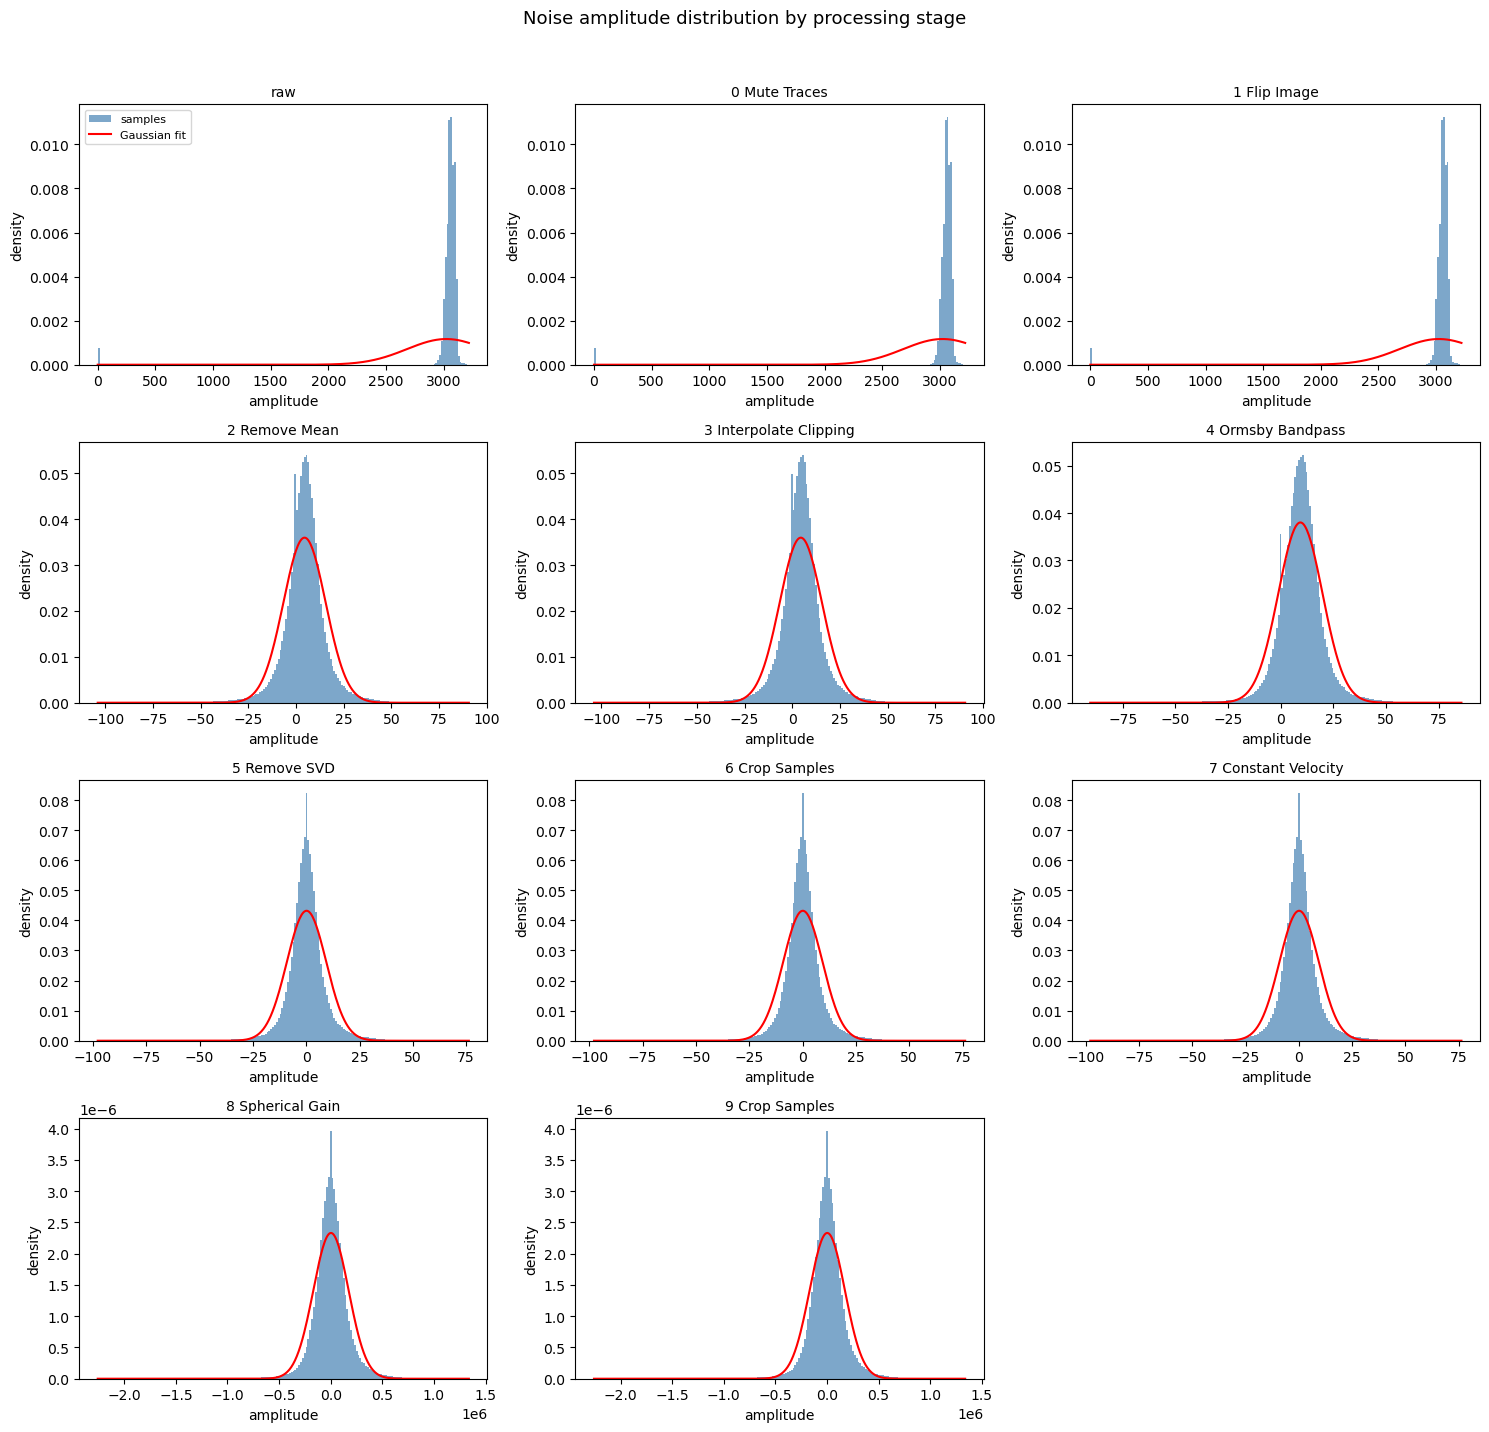

In [3]:
from scipy import stats

n_stages = len(stage_names)
ncols = 3
nrows = int(np.ceil(n_stages / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, stage_names):
    arr = np.asarray(noise_samples[name]).ravel()
    mu, sigma = arr.mean(), arr.std()

    ax.hist(arr, bins=200, density=True, color='steelblue', alpha=0.7, label='samples')

    x = np.linspace(arr.min(), arr.max(), 400)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=1.5, label='Gaussian fit')

    ax.set_title(name, fontsize=10)
    ax.set_xlabel('amplitude')
    ax.set_ylabel('density')

for ax in axes[n_stages:]:
    ax.axis('off')

axes[0].legend(fontsize=8)
fig.suptitle('Noise amplitude distribution by processing stage', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


Stage: 9 Crop Samples
Laplace fit:  loc=0.000  scale=117584.016
Gaussian fit: mu=2402.272  sigma=171156.107


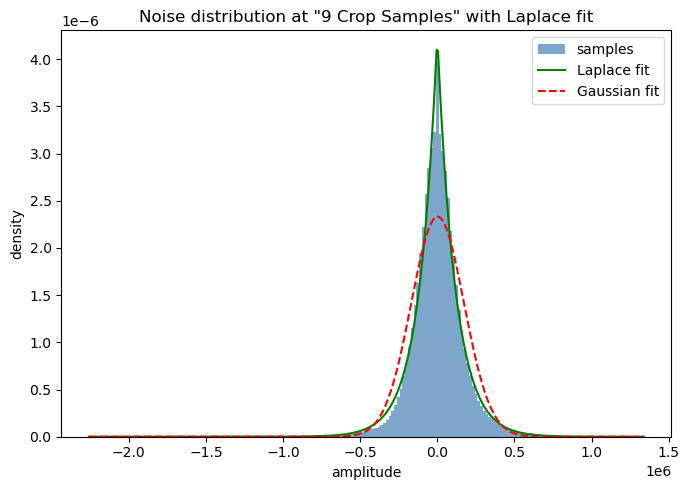

In [4]:
final_stage = stage_names[-1]
arr = np.asarray(noise_samples[final_stage]).ravel()

loc_laplace, scale_laplace = stats.laplace.fit(arr)
mu_gauss, sigma_gauss = arr.mean(), arr.std()

print(f"Stage: {final_stage}")
print(f"Laplace fit:  loc={loc_laplace:.3f}  scale={scale_laplace:.3f}")
print(f"Gaussian fit: mu={mu_gauss:.3f}  sigma={sigma_gauss:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(arr, bins=200, density=True, color='steelblue', alpha=0.7, label='samples')

x = np.linspace(arr.min(), arr.max(), 400)
ax.plot(x, stats.laplace.pdf(x, loc_laplace, scale_laplace), 'g-', lw=1.5, label='Laplace fit')
ax.plot(x, stats.norm.pdf(x, mu_gauss, sigma_gauss), 'r--', lw=1.5, label='Gaussian fit')

ax.set_title(f'Noise distribution at "{final_stage}" with Laplace fit')
ax.set_xlabel('amplitude')
ax.set_ylabel('density')
ax.legend()
fig.tight_layout()
plt.show()


# Noise from last stage

In [5]:
noise_model = {
    'distribution': 'laplace',
    'stage': final_stage,
    'loc': loc_laplace,
    'scale': scale_laplace,
    'n_samples_fit': arr.size,
}

model_path = Path.cwd() / 'laplace_noise_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(noise_model, f)

print(f"Saved noise model to {model_path}")
print(noise_model)


Saved noise model to c:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\laplace_noise_model.pkl
{'distribution': 'laplace', 'stage': '9 Crop Samples', 'loc': np.float64(0.0), 'scale': np.float64(117584.01555433117), 'n_samples_fit': 976244}


# Noise before gain

Stage: 7 Constant Velocity
Laplace fit:  loc=0.000  scale=6.085
Gaussian fit: mu=0.118  sigma=9.233


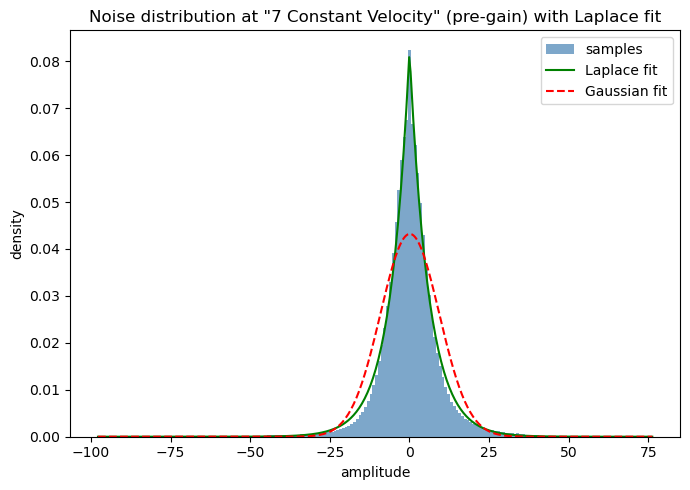

Saved noise model to c:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\laplace_noise_model_pre_gain.pkl
{'distribution': 'laplace', 'stage': '7 Constant Velocity', 'loc': np.float64(0.0), 'scale': np.float64(6.084582605057864), 'n_samples_fit': 976244}


In [6]:
pre_gain_stage = '7 Constant Velocity'   # last stage before "8 Spherical Gain"
arr_pre_gain = np.asarray(noise_samples[pre_gain_stage]).ravel()

loc_laplace_pre, scale_laplace_pre = stats.laplace.fit(arr_pre_gain)
mu_gauss_pre, sigma_gauss_pre = arr_pre_gain.mean(), arr_pre_gain.std()

print(f"Stage: {pre_gain_stage}")
print(f"Laplace fit:  loc={loc_laplace_pre:.3f}  scale={scale_laplace_pre:.3f}")
print(f"Gaussian fit: mu={mu_gauss_pre:.3f}  sigma={sigma_gauss_pre:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(arr_pre_gain, bins=200, density=True, color='steelblue', alpha=0.7, label='samples')

x = np.linspace(arr_pre_gain.min(), arr_pre_gain.max(), 400)
ax.plot(x, stats.laplace.pdf(x, loc_laplace_pre, scale_laplace_pre), 'g-', lw=1.5, label='Laplace fit')
ax.plot(x, stats.norm.pdf(x, mu_gauss_pre, sigma_gauss_pre), 'r--', lw=1.5, label='Gaussian fit')

ax.set_title(f'Noise distribution at "{pre_gain_stage}" (pre-gain) with Laplace fit')
ax.set_xlabel('amplitude')
ax.set_ylabel('density')
ax.legend()
fig.tight_layout()
plt.show()

# ── Save pre-gain noise model ───────────────────────────────────────────────
noise_model_pre_gain = {
    'distribution': 'laplace',
    'stage': pre_gain_stage,
    'loc': loc_laplace_pre,
    'scale': scale_laplace_pre,
    'n_samples_fit': arr_pre_gain.size,
}

model_path_pre_gain = Path.cwd() / 'laplace_noise_model_pre_gain.pkl'
with open(model_path_pre_gain, 'wb') as f:
    pickle.dump(noise_model_pre_gain, f)

print(f"Saved noise model to {model_path_pre_gain}")
print(noise_model_pre_gain)
